# Comparaison Heston (1993) / Heston-Nandi (2000) / CHJ (2009)

Analyse des résultats du batch de calibration : 10 actions du S&P 500 (5 secteurs),
6 dates de calibration réparties sur trois régimes de volatilité (juin 2024,
octobre 2024, avril 2025). Pour chaque calibration, je mesure la qualité du fit
in-sample puis la stabilité du pricing à J+1, J+3, J+7 et J+15 avec les
paramètres figés.

Ce notebook lit les parquets produits par `scripts/run_batch.py`. Aucune
recalibration ici : uniquement de la lecture, des figures et l'interprétation.

## 1. Chargement des résultats

In [1]:
import sys; sys.path.insert(0, '..')
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

MODEL_COLORS = {'heston93': '#1f77b4', 'hn2000': '#ff7f0e', 'chj2009': '#2ca02c'}
MODEL_NAMES  = {'heston93': 'Heston 93', 'hn2000': 'HN 00', 'chj2009': 'CHJ 09'}
REGIME_ORDER = ['calm', 'normal', 'stressed']
MODELS = ['heston93', 'hn2000', 'chj2009']

from src.config import load_config
from src.analysis import attach_sector, sectors_present, sector_coverage, tickers_in_sector
cfg = load_config('../config.yaml')
SECTOR_MAP = cfg.sectors
print(f'Secteurs déclarés : {list(SECTOR_MAP)}')

metrics = pd.read_parquet('../results/batch_results.parquet')
metrics['date'] = pd.to_datetime(metrics['date'])
metrics = attach_sector(metrics, SECTOR_MAP)

# Horizons OOS présents dans le parquet (adaptatif)
HORIZONS = sorted(set(
    int(c.split('_J')[1]) for c in metrics.columns
    if c.startswith('oos_iv_vega_rmse_J')
))
print(f'Horizons OOS disponibles : J+{HORIZONS}')

print('\nCouverture sectorielle :')
print(sector_coverage(metrics, SECTOR_MAP).to_string(index=False))

# Tableau récap adaptatif
oos_cols = [f'oos_iv_vega_rmse_J{h}' for h in HORIZONS if f'oos_iv_vega_rmse_J{h}' in metrics.columns]
recap = metrics[['date', 'ticker', 'sector', 'model', 'regime', 'n_options',
                  'in_sample_iv_vega_rmse'] + oos_cols + ['calibration_time_sec']].copy()
recap['date'] = recap['date'].dt.date
recap.round(3)

Secteurs déclarés : ['Tech', 'Consumer', 'Financials', 'Energy', 'Healthcare']
Horizons OOS disponibles : J+[1, 3, 7, 15]

Couverture sectorielle :
    sector  n_declared  n_calibrated          tickers
      Tech           3             3 AAPL, MSFT, NVDA
  Consumer           2             2         AMZN, PG
Financials           2             2          GS, JPM
    Energy           2             2         CVX, XOM
Healthcare           1             1              UNH


,date,ticker,sector,model,regime,n_options,in_sample_iv_vega_rmse,oos_iv_vega_rmse_J1,oos_iv_vega_rmse_J3,oos_iv_vega_rmse_J7,oos_iv_vega_rmse_J15,calibration_time_sec
0,2024-06-03,AAPL,Tech,heston93,calm,252,0.761,0.784,0.760,0.890,0.982,29.971
1,2024-06-03,AAPL,Tech,hn2000,calm,252,0.770,0.792,0.766,1.066,1.006,219.335
2,2024-06-03,AAPL,Tech,chj2009,calm,252,0.712,0.729,0.719,0.839,1.356,194.372
3,2024-06-03,MSFT,Tech,heston93,calm,371,1.625,1.669,1.749,1.838,2.318,34.334
4,2024-06-03,MSFT,Tech,hn2000,calm,371,1.704,1.695,1.852,2.084,2.631,111.415
...,...,...,...,...,...,...,...,...,...,...,...,...
175,2025-04-02,PG,Consumer,hn2000,stressed,47,0.415,0.817,1.857,1.763,1.176,168.351
176,2025-04-02,PG,Consumer,chj2009,stressed,47,0.413,0.678,2.049,1.475,1.292,143.250
177,2025-04-02,UNH,Healthcare,heston93,stressed,177,1.814,2.617,7.105,2.425,3.292,16.500
178,2025-04-02,UNH,Healthcare,hn2000,stressed,177,1.849,2.994,7.983,4.153,3.311,105.711


### Choix des régimes de volatilité

Les trois mois de test ont été choisis en regardant le VIX : juin 2024 pour le
régime calme (VIX moyen ~12.7), octobre 2024 pour le régime normal (~20.0) et
avril 2025 pour le régime stressé (~32, pic qui suit l'annonce des tarifs
douaniers américains). Les seuils calm < 15 et stressed > 25 sont arbitraires
mais classiques. La cellule vérifie que le VIX moyen de chaque mois tombe bien
dans le régime annoncé.

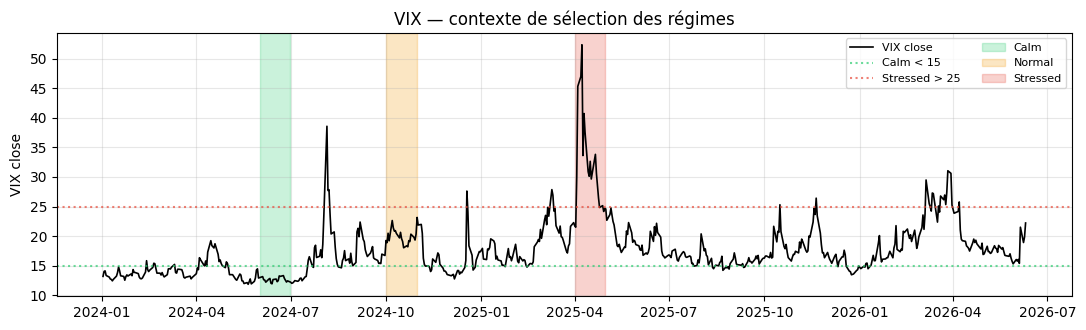

VIX moyen dans chaque mois de test :
  calm       2024-06-01 -> 2024-06-30: VIX moy = 12.7  -> calm
  normal     2024-10-01 -> 2024-10-31: VIX moy = 20.0  -> normal
  stressed   2025-04-01 -> 2025-04-30: VIX moy = 32.0  -> stressed


In [2]:
vix_path = cfg.vix_file
if vix_path is None or not vix_path.exists():
    raise FileNotFoundError('VIX file not configured or not found — set `vix_file` in config.yaml')

vix = pd.read_parquet(vix_path, columns=['created', 'close']).rename(
    columns={'created': 'date', 'close': 'vix'})
vix['date'] = pd.to_datetime(vix['date']).dt.tz_localize(None).dt.normalize()
vix = vix.sort_values('date').reset_index(drop=True)

REGIME_COLORS = {'calm': '#2ecc71', 'normal': '#f39c12', 'stressed': '#e74c3c'}
CALM_THRESHOLD = 15.0
STRESS_THRESHOLD = 25.0

fig, ax = plt.subplots(figsize=(11, 3.4))
ax.plot(vix.date, vix.vix, color='black', linewidth=1.2, label='VIX close')

# Seuils horizontaux pour la classification
ax.axhline(CALM_THRESHOLD, color=REGIME_COLORS['calm'], linestyle=':', alpha=0.7,
           label=f'Calm < {CALM_THRESHOLD:.0f}')
ax.axhline(STRESS_THRESHOLD, color=REGIME_COLORS['stressed'], linestyle=':', alpha=0.7,
           label=f'Stressed > {STRESS_THRESHOLD:.0f}')

# Bandes verticales pour les mois de test
labels_done = set()
for regime, dates_list in cfg.oos['test_months'].items():
    for d in dates_list:
        d = pd.Timestamp(d)
        end = d + pd.offsets.MonthEnd(0)
        lbl = regime.capitalize() if regime not in labels_done else None
        ax.axvspan(d, end, alpha=0.25, color=REGIME_COLORS.get(regime, 'gray'),
                   label=lbl)
        labels_done.add(regime)

ax.set_ylabel('VIX close')
ax.set_title('VIX — contexte de sélection des régimes')
ax.legend(loc='upper right', fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig('../results/figures/00_vol_context.png', dpi=120, bbox_inches='tight')
plt.show()

# Diagnostic : VIX moyen pendant chacun des mois de test
print('VIX moyen dans chaque mois de test :')
for regime, dates_list in cfg.oos['test_months'].items():
    for d in dates_list:
        d = pd.Timestamp(d)
        end = d + pd.offsets.MonthEnd(0)
        m_vix = vix[(vix.date >= d) & (vix.date <= end)].vix.mean()
        cls = 'calm' if m_vix < CALM_THRESHOLD else ('stressed' if m_vix > STRESS_THRESHOLD else 'normal')
        ok = '' if cls == regime else f'  != label "{regime}"'
        print(f'  {regime:10s} {d.date()} -> {end.date()}: VIX moy = {m_vix:.1f}  -> {cls}{ok}')

## 2. Qualité du fit in-sample

RMSE sur la volatilité implicite, en points de vol, moyenné par secteur et
régime. Je préfère cette métrique à la loss vega-pondérée utilisée pour la
calibration : le vega Black-Scholes est proportionnel au spot, donc la loss
n'est pas comparable d'un ticker à l'autre, alors qu'un RMSE IV de 2 points de
vol veut dire la même chose partout.

À garder en tête pour la lecture : CHJ contient Heston comme cas particulier
(il suffit d'éteindre le second facteur), donc il devrait *toujours* faire au
moins aussi bien in-sample. Les cas où Heston passe devant signalent une
calibration de CHJ tombée dans un minimum local, pas un meilleur modèle.

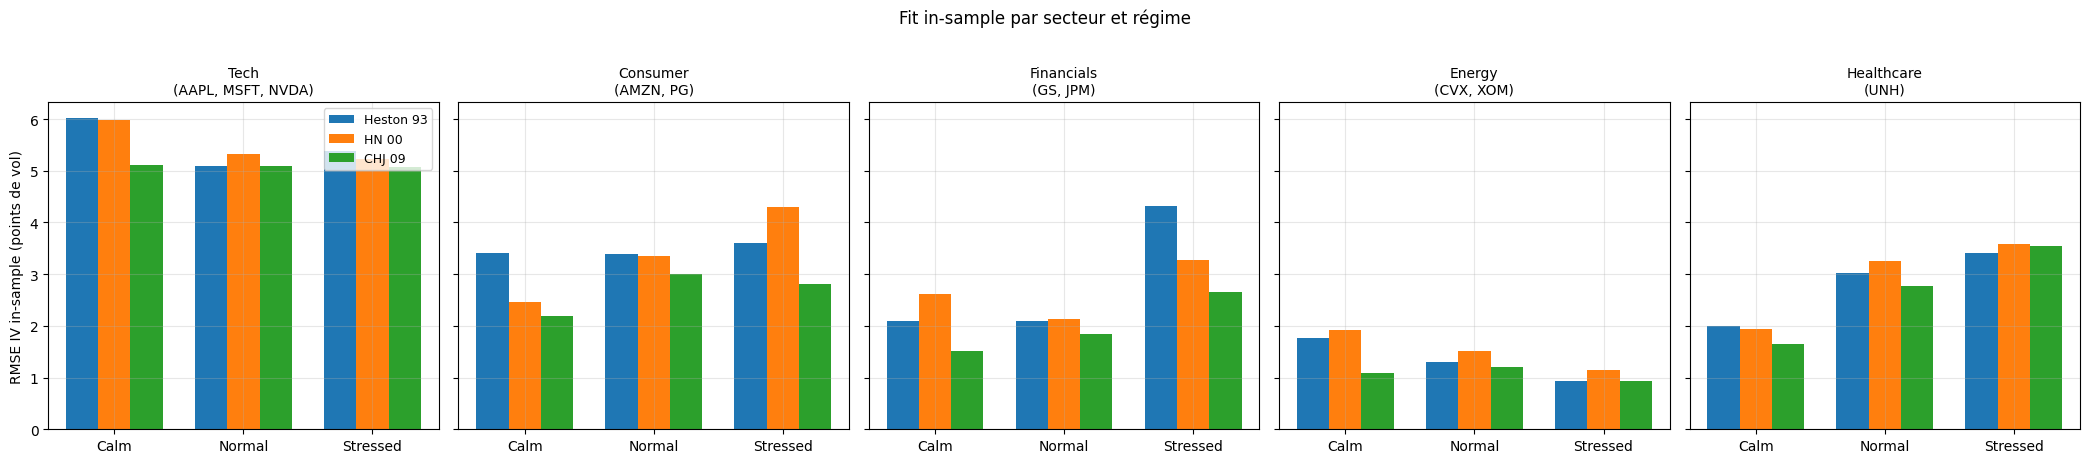

In [3]:
# Pour chaque secteur : RMSE IV in-sample moyen (en points de vol) par régime
sectors = sectors_present(metrics, SECTOR_MAP)
n_sec = len(sectors)
fig, axes = plt.subplots(1, n_sec, figsize=(4.2 * n_sec, 4.5), sharey=True)
axes = np.atleast_1d(axes)

x = np.arange(len(REGIME_ORDER))
w = 0.25

for ax, sec in zip(axes, sectors):
    sub = metrics[metrics.sector == sec]
    tickers_sec = sorted(sub.ticker.unique())
    for i, m in enumerate(MODELS):
        vals = [
            sub[(sub.regime == r) & (sub.model == m)]['in_sample_rmse_iv'].mean() * 100
            for r in REGIME_ORDER
        ]
        ax.bar(x + (i - 1) * w, vals, w, label=MODEL_NAMES[m], color=MODEL_COLORS[m])
    ax.set_xticks(x)
    ax.set_xticklabels([r.capitalize() for r in REGIME_ORDER])
    ax.set_title(f'{sec}\n({", ".join(tickers_sec)})', fontsize=10)
    if ax is axes[0]:
        ax.set_ylabel('RMSE IV in-sample (points de vol)')
        ax.legend(fontsize=9)

fig.suptitle('Fit in-sample par secteur et régime', y=1.02)
plt.tight_layout()
plt.savefig('../results/figures/01_in_sample_by_sector.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Fit du smile de volatilité

Le test visuel le plus parlant. Courbe noire = IV de marché moyenne (bande
grise = ±1σ entre tickers et dates du régime), courbes colorées = smile
re-pricé par chaque modèle calibré, sur une grille de moneyness. Une figure
par secteur, en grille bucket de maturité × régime.

On voit directement où chaque modèle décroche : les courtes maturités et
l'aile gauche (puts OTM) sont les zones difficiles.

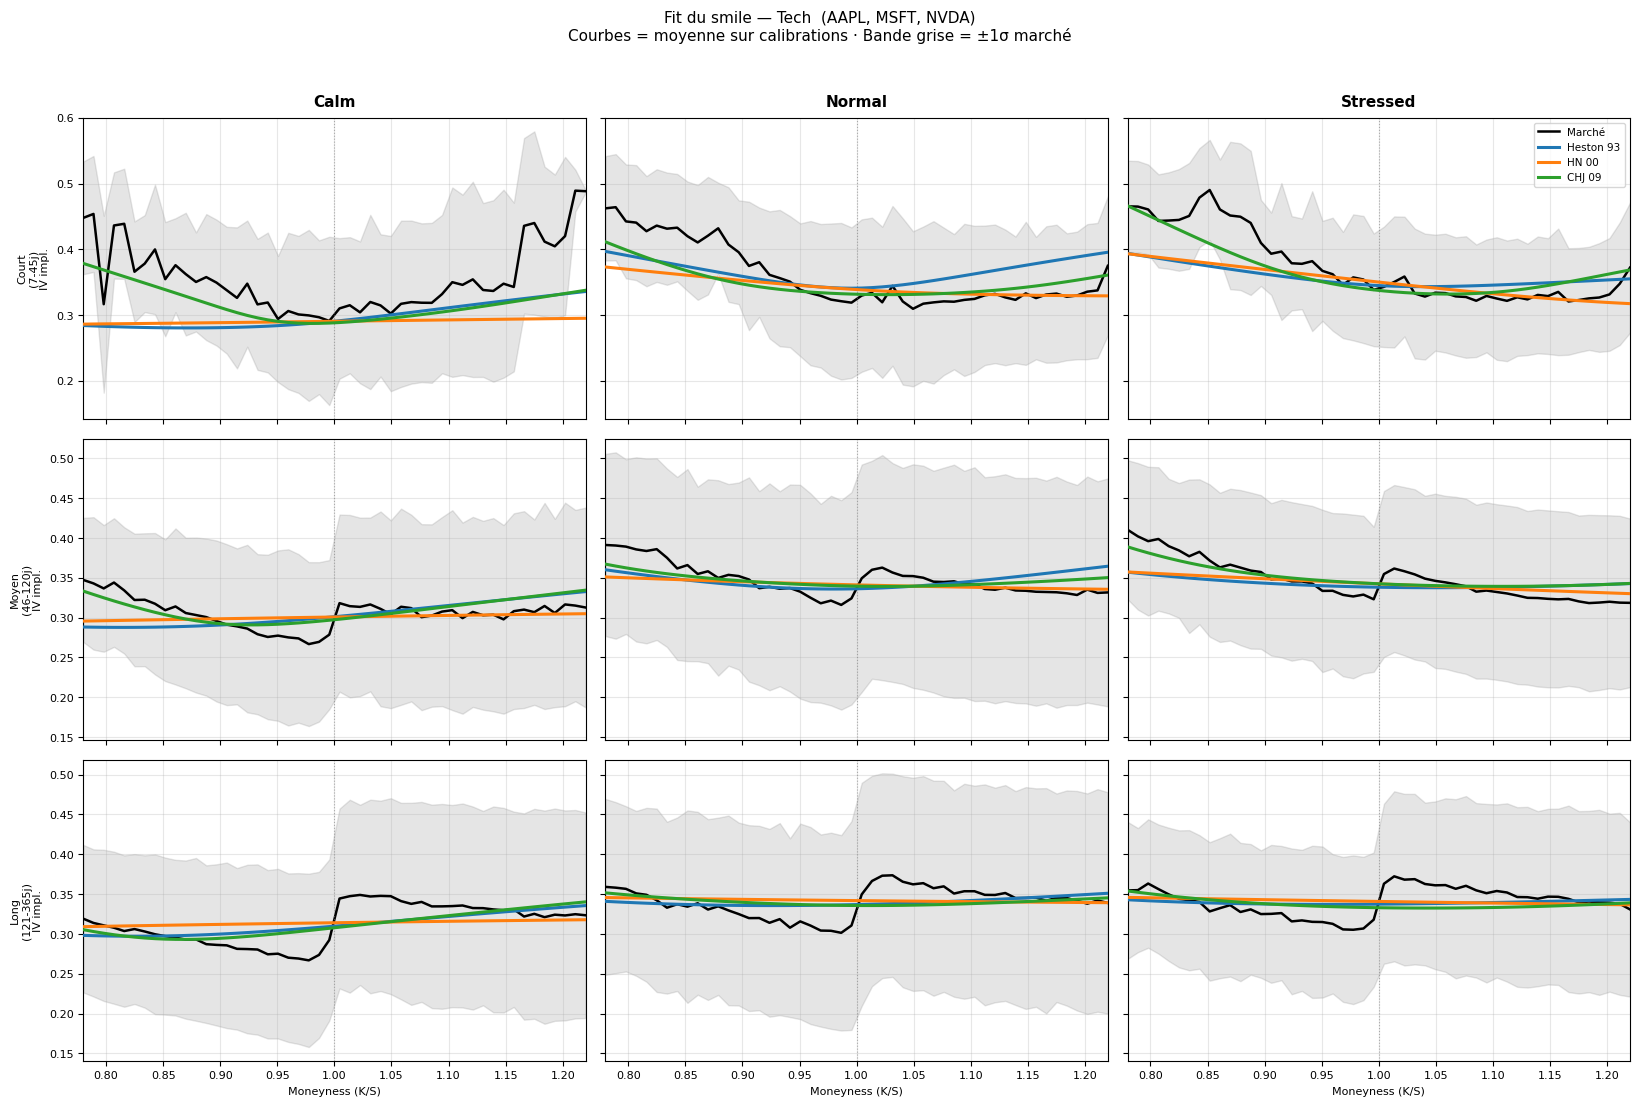

Saved: ../results/figures/02_smile_tech.png


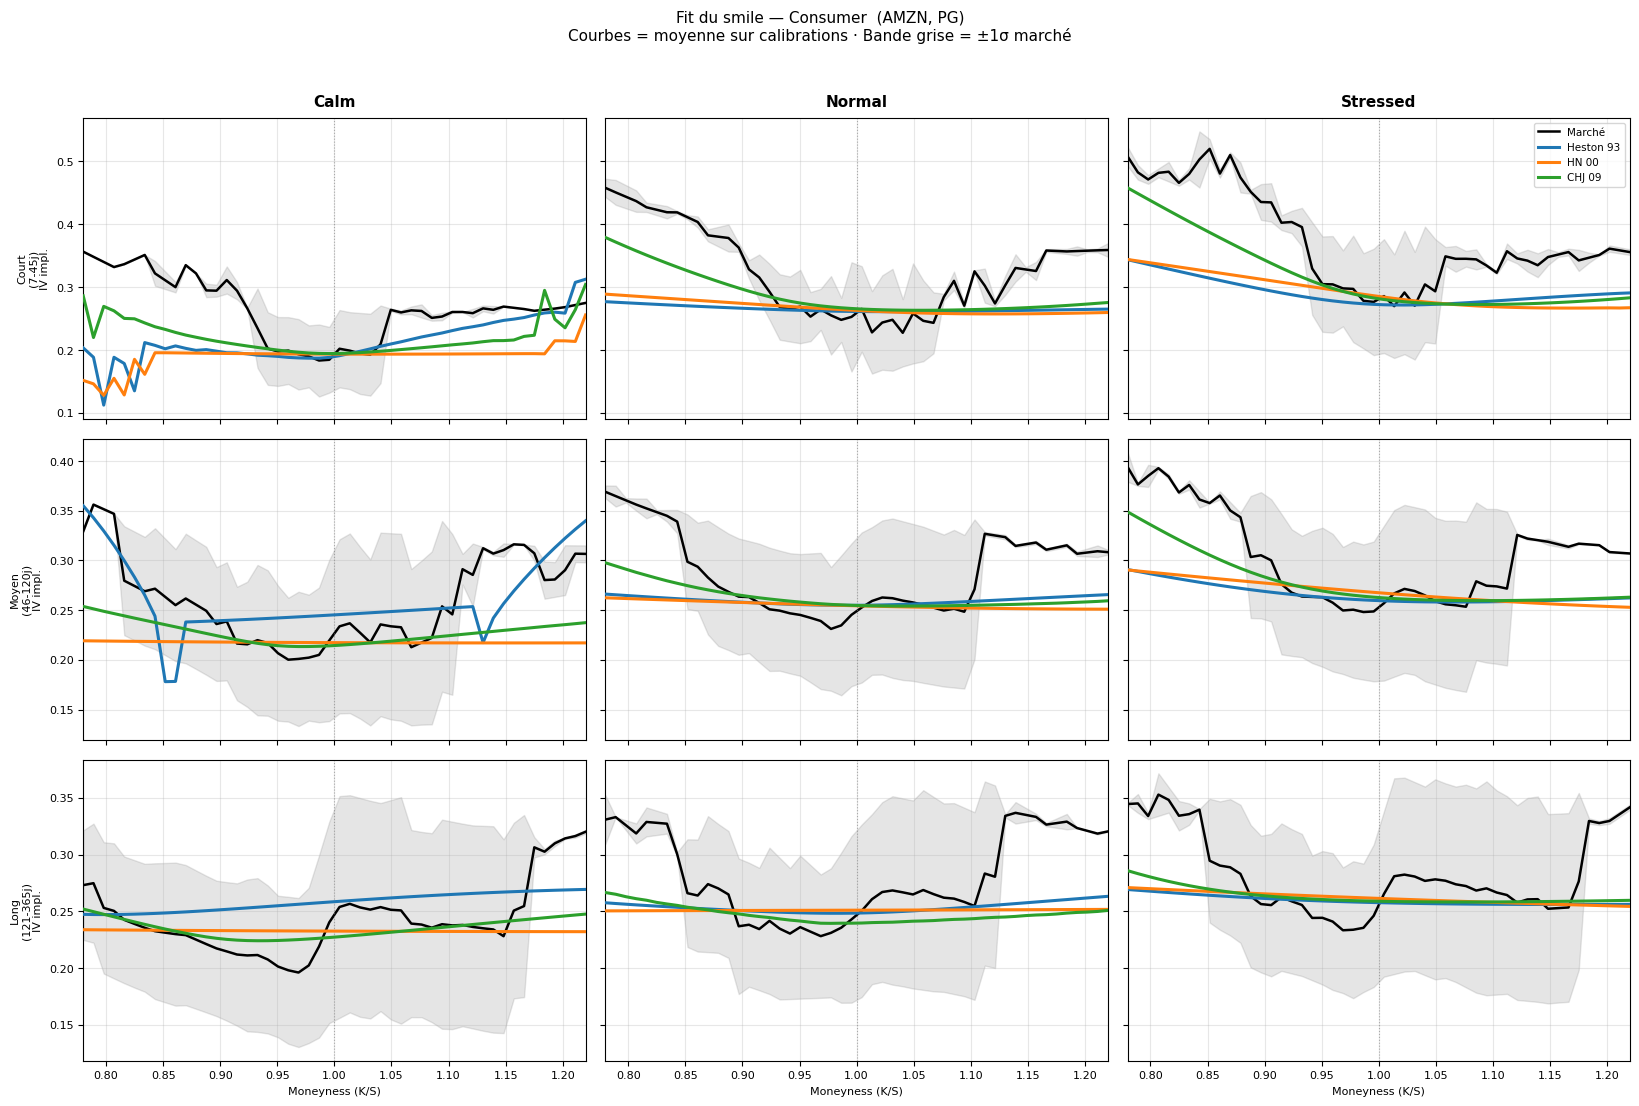

Saved: ../results/figures/02_smile_consumer.png


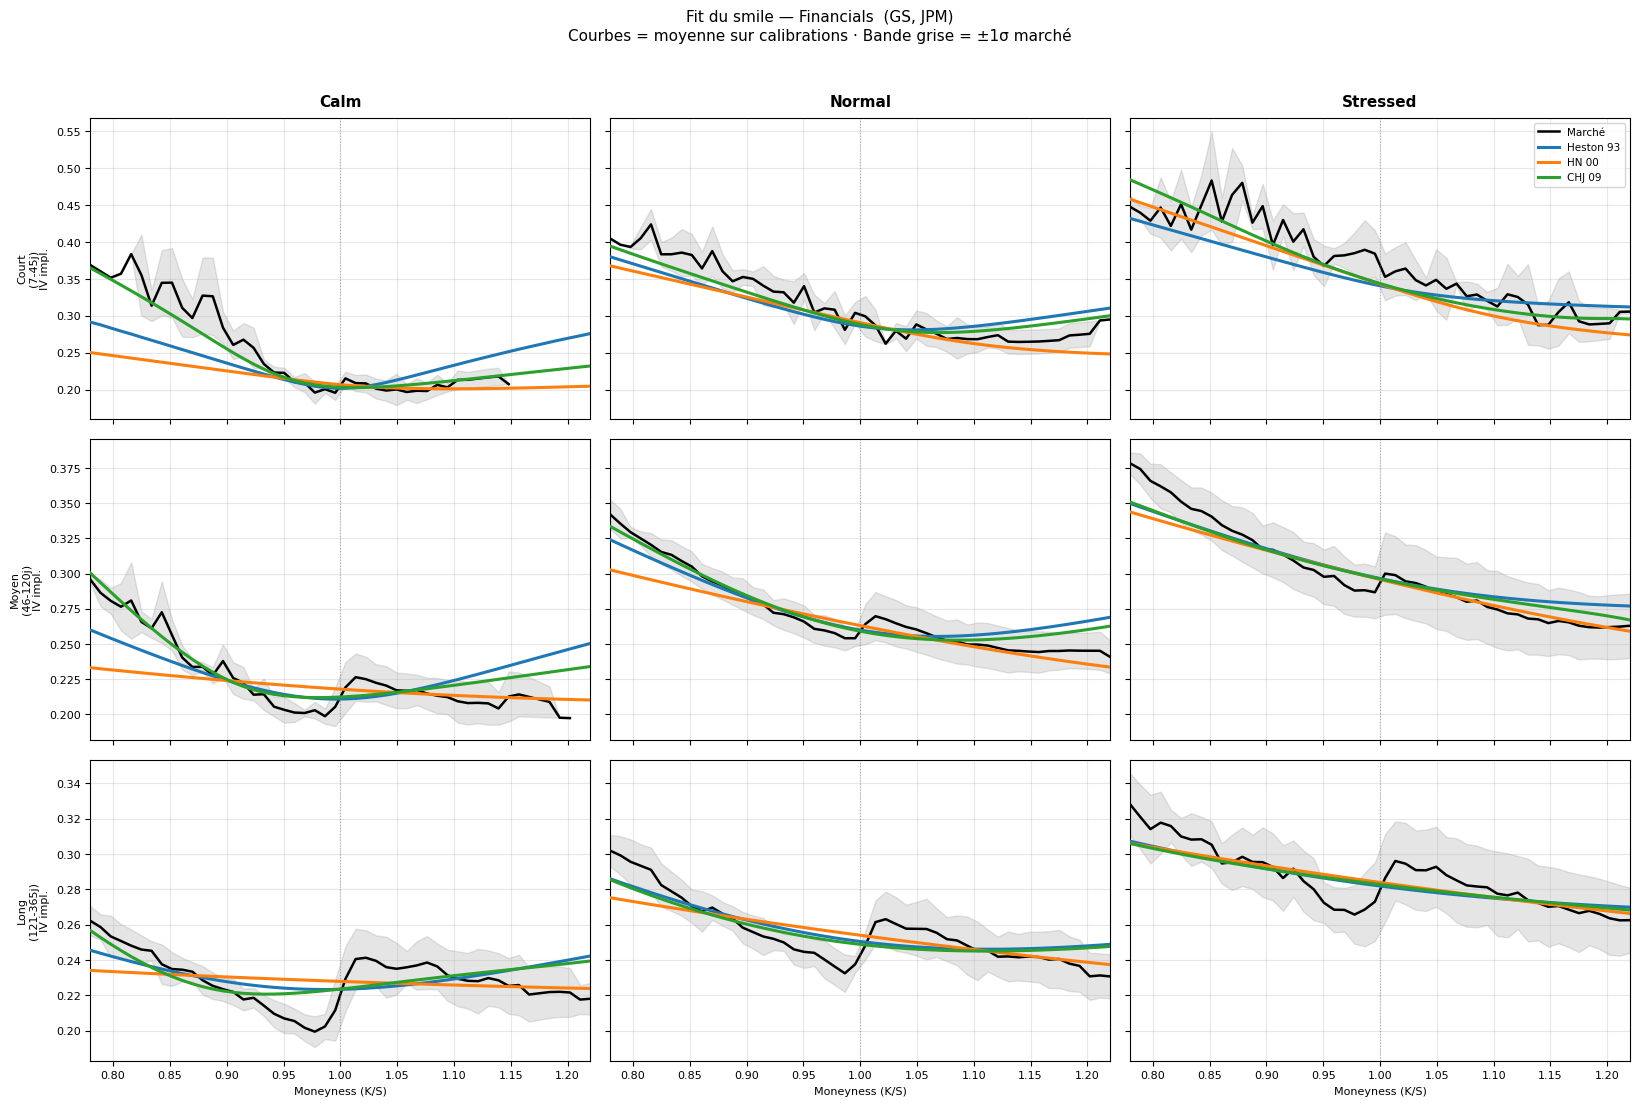

Saved: ../results/figures/02_smile_financials.png


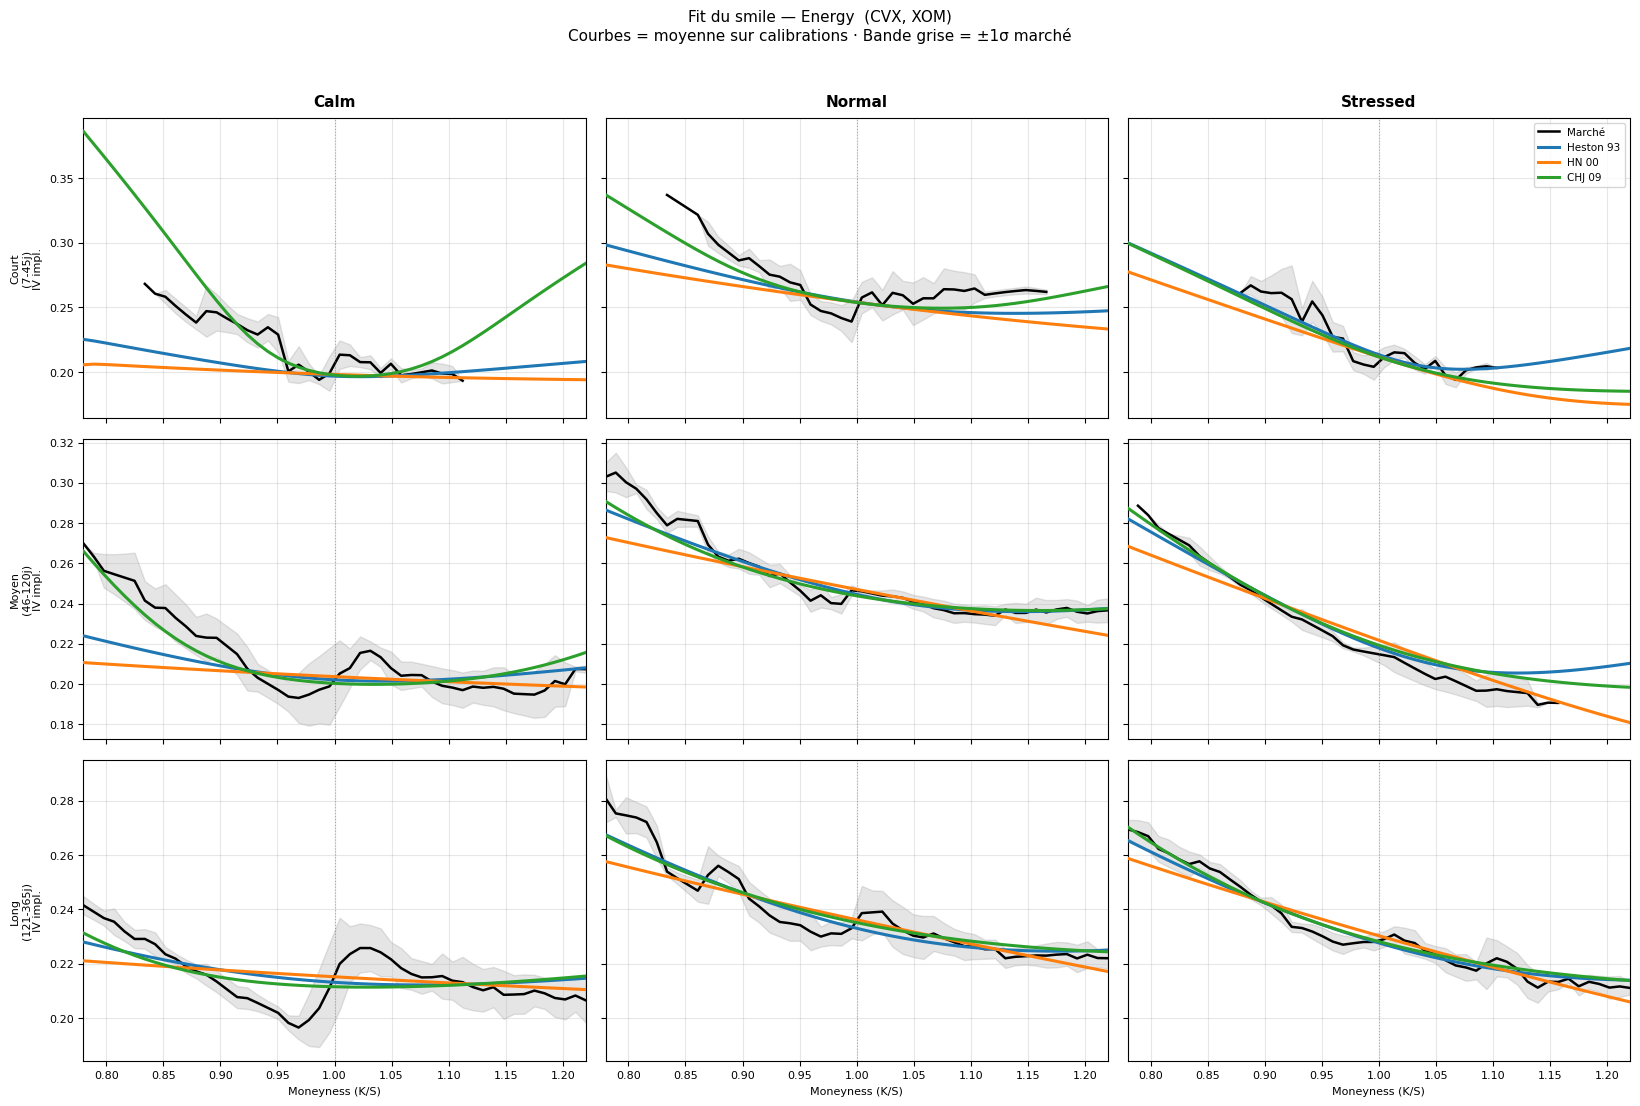

Saved: ../results/figures/02_smile_energy.png


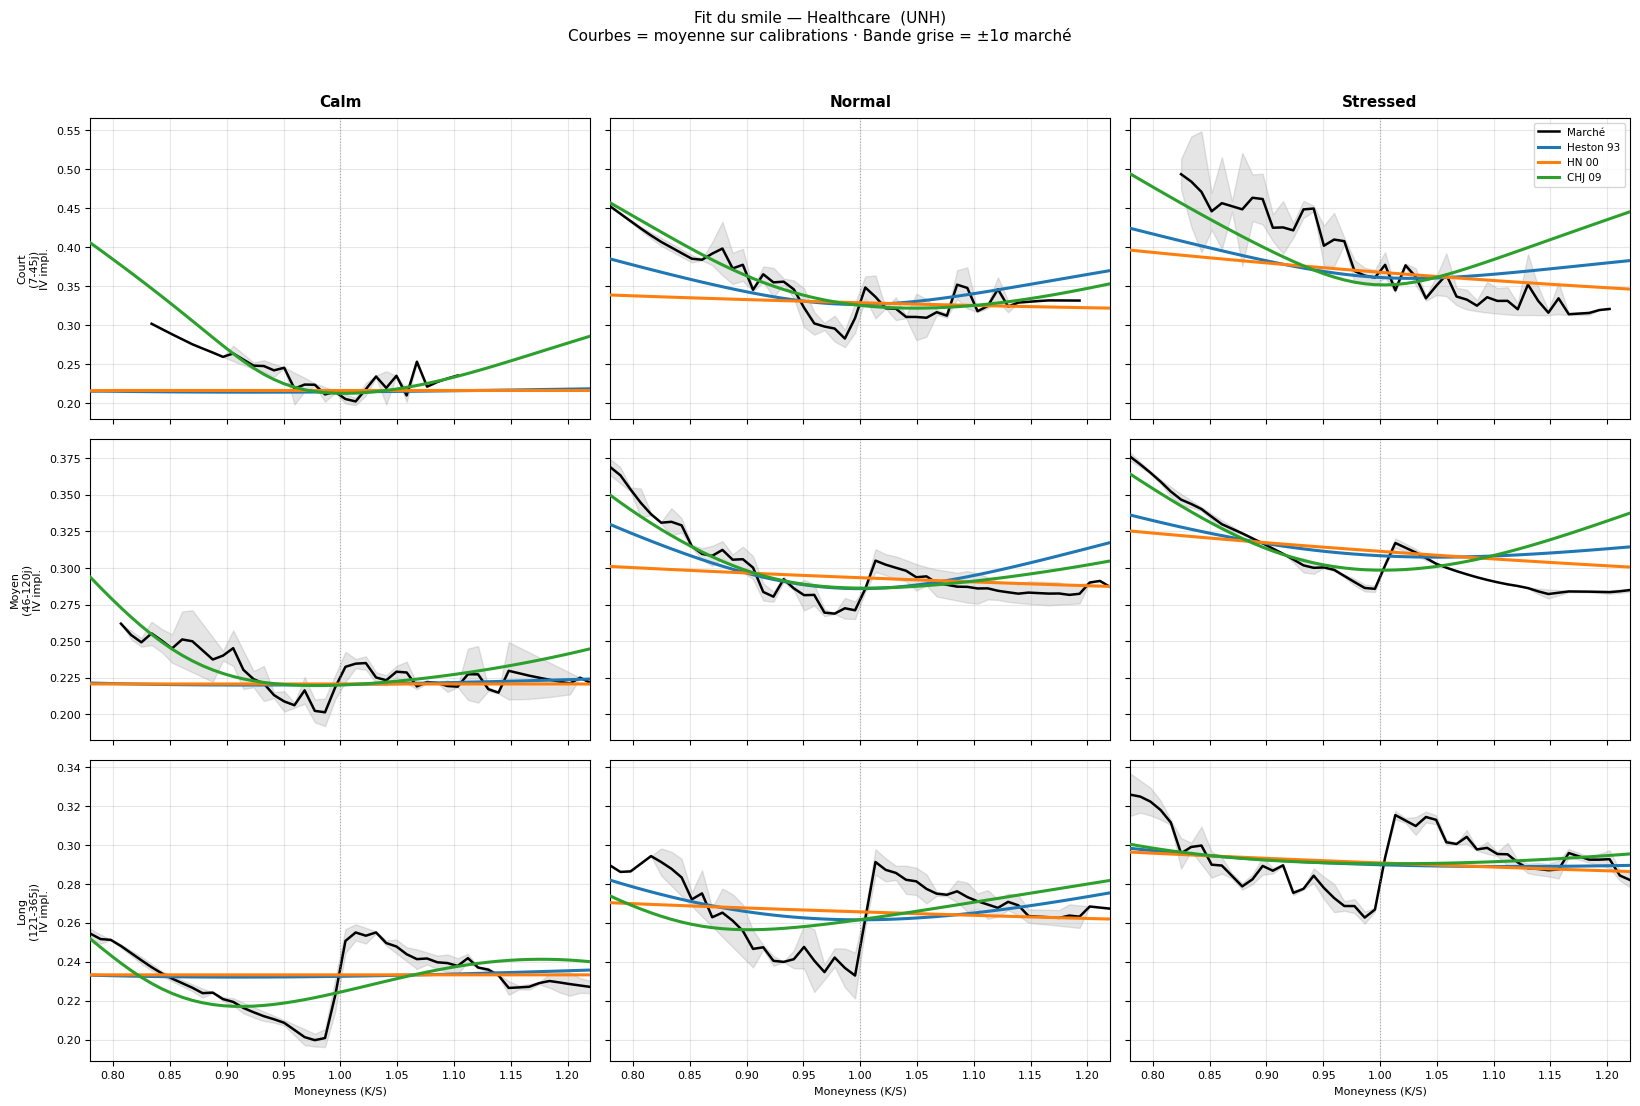

Saved: ../results/figures/02_smile_healthcare.png


In [4]:
from src.preprocessing import load_chain, FilterConfig, filter_chain, add_implied_vol
from src.models import MODEL_REGISTRY, implied_vol_vec
from matplotlib.lines import Line2D

filt_cfg    = FilterConfig(**cfg.filters, r_annual=cfg.calibration['r_annual'])
params_long = pd.read_parquet('../results/params_long.parquet')
params_long['date'] = pd.to_datetime(params_long['date'])

sectors = sectors_present(metrics, SECTOR_MAP)
regimes = [r for r in ['calm', 'normal', 'stressed'] if r in metrics.regime.values]

DTE_BUCKETS = [
    ('Court\n(7-45j)',    7,   45),
    ('Moyen\n(46-120j)', 46,  120),
    ('Long\n(121-365j)', 121, 365),
]
MON_GRID = np.linspace(0.78, 1.22, 50)
R_F = cfg.calibration['r_annual']


def _market_iv_on_grid(d, ticker, dte_lo, dte_hi):
    try:
        chain = load_chain(d, ticker, cfg.data_root)
    except Exception:
        return None
    clean = filter_chain(chain, filt_cfg)
    clean = add_implied_vol(clean, R_F)
    sm = clean[(clean.dte >= dte_lo) & (clean.dte <= dte_hi) & (clean.iv > 0.05)]
    if len(sm) < 4:
        return None
    sm = sm.sort_values('moneyness')
    return np.interp(MON_GRID, sm.moneyness.values, sm.iv.values,
                     left=np.nan, right=np.nan)


def _model_iv_on_grid(d, ticker, dte_lo, dte_hi, model_name):
    try:
        chain = load_chain(d, ticker, cfg.data_root)
    except Exception:
        return None
    clean = filter_chain(chain, filt_cfg)
    clean = add_implied_vol(clean, R_F)
    sm = clean[(clean.dte >= dte_lo) & (clean.dte <= dte_hi) & (clean.iv > 0.05)]
    if len(sm) < 4:
        return None
    sub = params_long[(params_long.date == d) & (params_long.ticker == ticker)
                      & (params_long.model == model_name)]
    if sub.empty:
        return None
    pricer = MODEL_REGISTRY[model_name].from_calibration_vector(
        sub['param_value'].to_numpy(), r_f=R_F)
    spot    = sm.spot.mean()
    T       = sm.dte.mean() / 365
    strikes = MON_GRID * spot
    # price_chain(S, K, T, rights) — r_f is stored in pricer, not a parameter
    prices = pricer.price_chain(
        np.full(len(MON_GRID), spot),
        strikes,
        np.full(len(MON_GRID), T),
        np.array(['C'] * len(MON_GRID)),
    )
    return implied_vol_vec(prices,
                           np.full(len(MON_GRID), spot), strikes,
                           np.full(len(MON_GRID), T), R_F,
                           np.array(['C'] * len(MON_GRID)))


# ── une figure par secteur ────────────────────────────────────────────────────
for sec in sectors:
    tickers_sec = tickers_in_sector(sec, metrics, SECTOR_MAP)
    n_reg = len(regimes)
    n_bkt = len(DTE_BUCKETS)

    fig, axes = plt.subplots(n_bkt, n_reg,
                             figsize=(5.5 * n_reg, 3.6 * n_bkt),
                             sharex=True, sharey='row')
    axes = np.array(axes).reshape(n_bkt, n_reg)

    for j, regime in enumerate(regimes):
        dates_reg = sorted(metrics[(metrics.sector == sec) & (metrics.regime == regime)]
                           .date.unique())

        for i, (bkt_label, dte_lo, dte_hi) in enumerate(DTE_BUCKETS):
            ax = axes[i, j]

            # Marché : bande grise = moy ± std
            mkt_curves = []
            for d in dates_reg:
                for t in tickers_sec:
                    iv = _market_iv_on_grid(d, t, dte_lo, dte_hi)
                    if iv is not None:
                        mkt_curves.append(iv)

            if mkt_curves:
                mkt = np.array(mkt_curves)
                mu  = np.nanmean(mkt, axis=0)
                sig = np.nanstd(mkt,  axis=0)
                ax.fill_between(MON_GRID, mu - sig, mu + sig,
                                color='#555555', alpha=0.15, zorder=1)
                ax.plot(MON_GRID, mu, color='black', lw=1.8, label='Marché', zorder=2)

            # Modèles : courbe moyenne
            for m in MODELS:
                mod_curves = []
                for d in dates_reg:
                    for t in tickers_sec:
                        iv = _model_iv_on_grid(d, t, dte_lo, dte_hi, m)
                        if iv is not None:
                            mod_curves.append(iv)
                if not mod_curves:
                    continue
                mean_iv = np.nanmean(np.array(mod_curves), axis=0)
                ax.plot(MON_GRID, mean_iv, lw=2.2,
                        color=MODEL_COLORS[m], label=MODEL_NAMES[m], zorder=3)

            ax.axvline(1.0, color='gray', ls=':', lw=0.8, alpha=0.6)
            ax.set_xlim(MON_GRID[0], MON_GRID[-1])
            ax.tick_params(labelsize=8)
            if i == 0:
                ax.set_title(regime.capitalize(), fontsize=11, fontweight='bold', pad=8)
            if j == 0:
                ax.set_ylabel(f'{bkt_label}\nIV impl.', fontsize=8)
            if i == n_bkt - 1:
                ax.set_xlabel('Moneyness (K/S)', fontsize=8)
            if i == 0 and j == n_reg - 1:
                ax.legend(fontsize=7.5, loc='upper right')

    fig.suptitle(f'Fit du smile — {sec}  ({", ".join(tickers_sec)})\n'
                 f'Courbes = moyenne sur calibrations · Bande grise = ±1σ marché',
                 fontsize=11, y=1.02)
    plt.tight_layout()
    fname = f'../results/figures/02_smile_{sec.lower()}.png'
    plt.savefig(fname, dpi=140, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fname}")

## 4. Dégradation hors-échantillon

Les paramètres calibrés au jour J sont figés, puis servent à pricer les
chaînes observées à J+1, J+3, J+7 et J+15. Seule exception : pour HN, la
variance conditionnelle `h_t` est mise à jour via la récursion GARCH avec les
returns réalisés entre J et J+k (c'est le fonctionnement normal du modèle, les
autres paramètres restent figés).

Une courbe plate = des paramètres qui restent valables plusieurs jours. Une
courbe qui monte vite dès J+1 = des paramètres qui collaient au panel du jour
sans généraliser. En ordonnée, RMSE IV en points de vol, bande = ±1 erreur
standard.

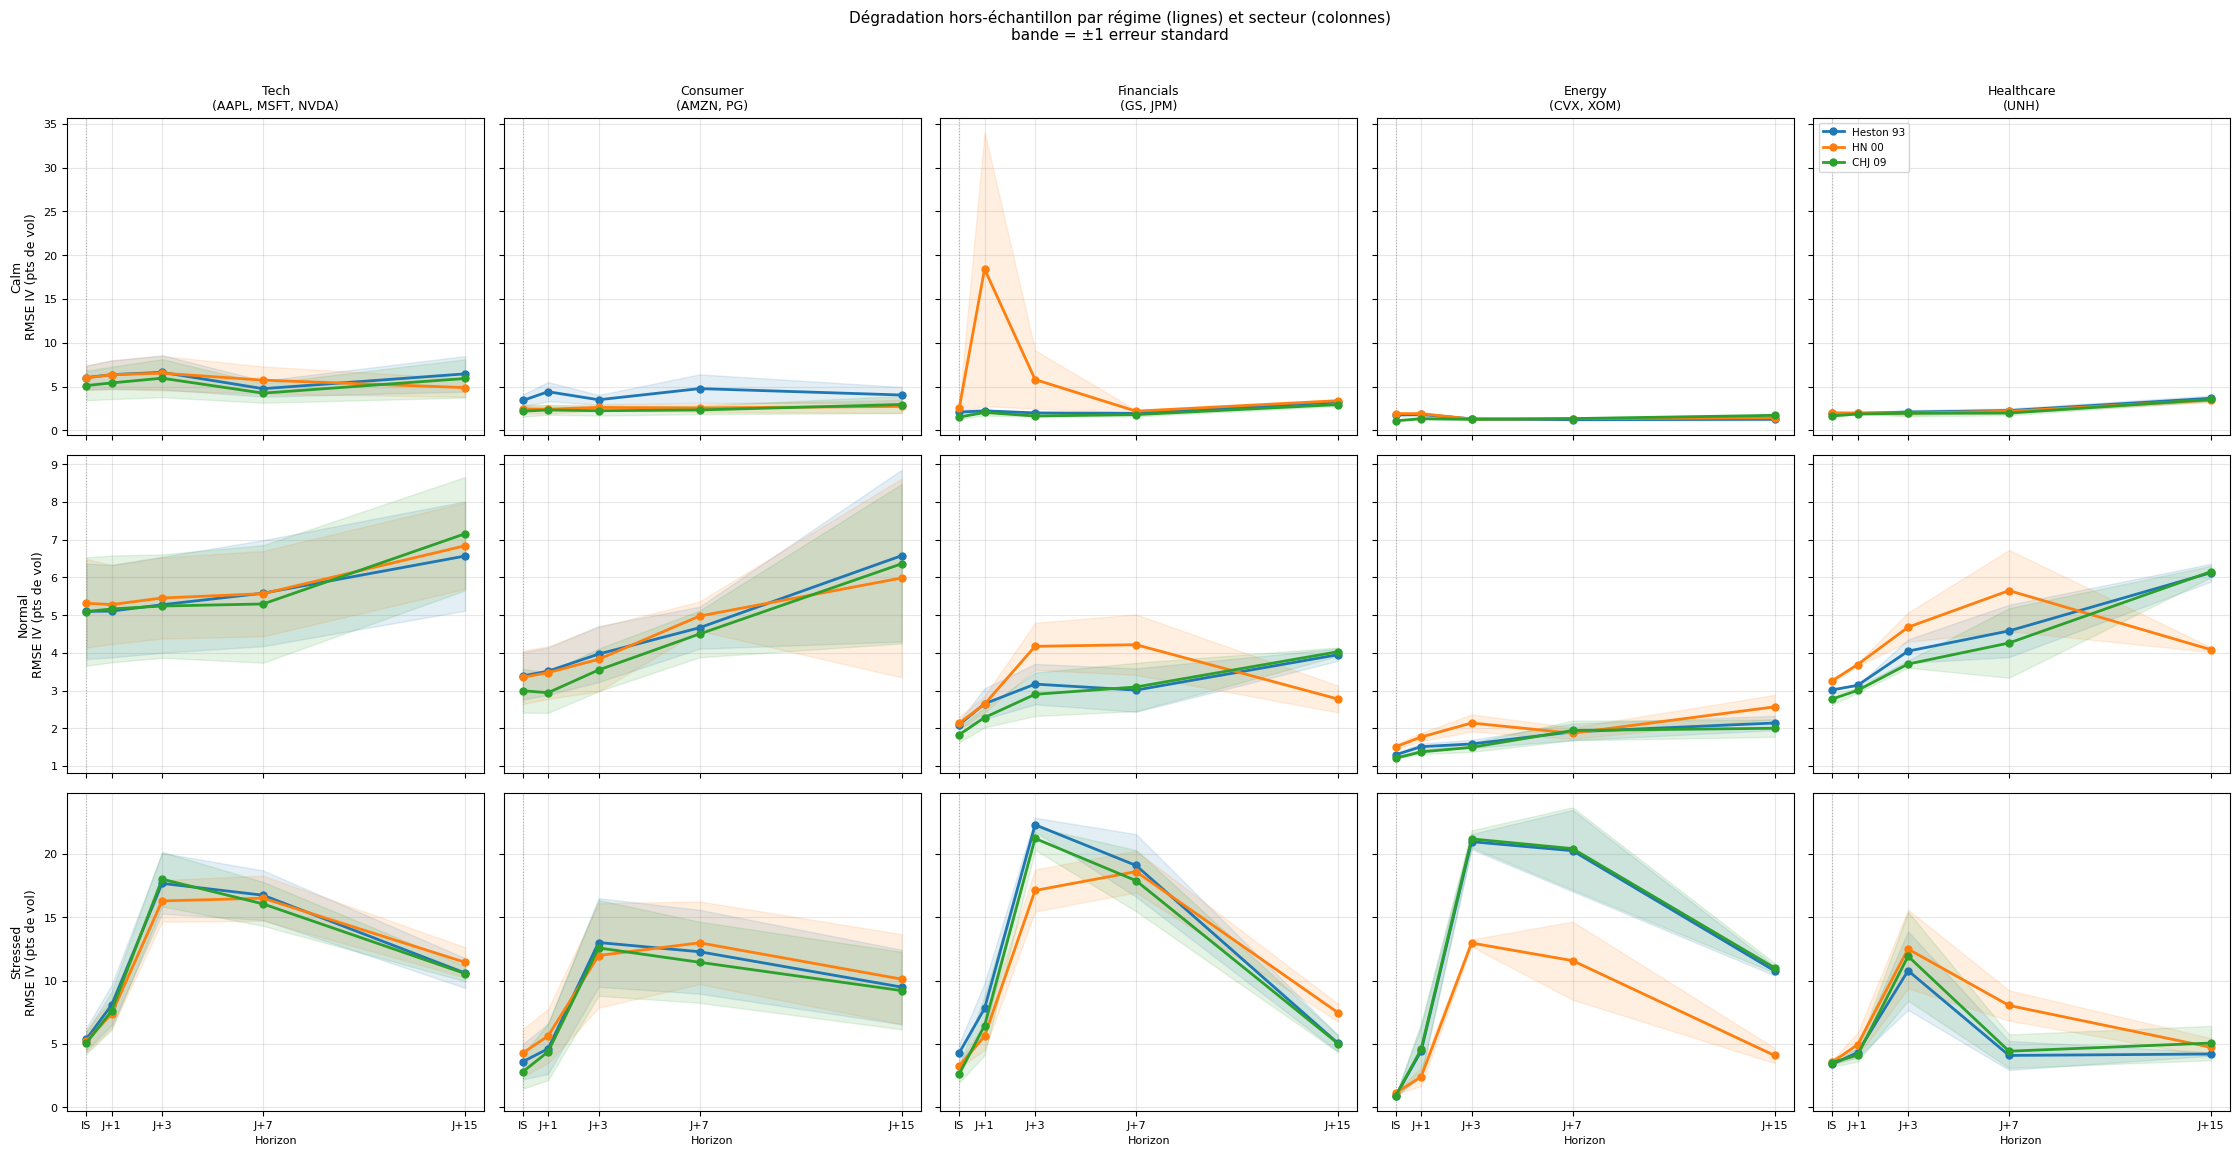

IS    J+1    J+3    J+7   J+15    Gap
regime   sector     model                                             
calm     Tech       Heston 93  6.03   6.37   6.63   4.76   6.45   0.43
         Consumer   Heston 93  3.42   4.42   3.50   4.77   4.04   0.62
         Financials Heston 93  2.09   2.23   2.00   1.95   3.25   1.16
         Energy     Heston 93  1.76   1.82   1.32   1.22   1.27  -0.50
         Healthcare Heston 93  1.99   1.95   2.09   2.26   3.67   1.68
         Tech       HN 00      5.99   6.36   6.53   5.74   4.88  -1.11
         Consumer   HN 00      2.46   2.42   2.62   2.57   2.74   0.28
         Financials HN 00      2.61  18.42   5.81   2.20   3.39   0.78
         Energy     HN 00      1.92   1.91   1.30   1.34   1.43  -0.48
         Healthcare HN 00      1.94   1.99   1.98   2.18   3.46   1.52
         Tech       CHJ 09     5.12   5.42   5.96   4.25   5.93   0.81
         Consumer   CHJ 09     2.19   2.33   2.24   2.33   2.95   0.76
         Financials CHJ 09     1.52   2.05   1.64   1.80   2.94   1.42
         Energy     CHJ 09     1.10   1.34   1.26   1.35   1.72   0.62
         Healthcare CHJ 09     1.65   1.87   1.96   1.98   3.53   1.88
normal   Tech       Heston 93  5.10   5.11   5.28   5.58   6.57   1.47
         Consumer   Heston 93  3.39   3.52   3.97   4.67   6.58   3.19
         Financials Heston 93  2.10   2.65   3.17   3.01   3.95   1.85
         Energy     Heston 93  1.30   1.51   1.58   1.91   2.14   0.84
         Healthcare Heston 93  3.02   3.14   4.05   4.58   6.13   3.11
         Tech       HN 00      5.32   5.28   5.46   5.57   6.84   1.52
         Consumer   HN 00      3.35   3.48   3.83   4.98   5.99   2.63
         Financials HN 00      2.14   2.64   4.17   4.22   2.78   0.64
         Energy     HN 00      1.51   1.77   2.14   1.87   2.57   1.06
         Healthcare HN 00      3.26   3.69   4.68   5.65   4.08   0.82
         Tech       CHJ 09     5.10   5.17   5.24   5.30   7.16   2.06
         Consumer   CHJ 09     3.00   2.94   3.55   4.50   6.36   3.37
         Financials CHJ 09     1.83   2.29   2.90   3.10   4.03   2.20
         Energy     CHJ 09     1.21   1.37   1.49   1.94   2.00   0.79
         Healthcare CHJ 09     2.78   3.01   3.70   4.26   6.16   3.38
stressed Tech       Heston 93  5.39   8.08  17.68  16.75  10.61   5.22
         Consumer   Heston 93  3.61   4.63  13.01  12.29   9.50   5.89
         Financials Heston 93  4.31   7.81  22.31  19.09   5.05   0.74
         Energy     Heston 93  0.93   4.43  20.97  20.26  10.78   9.85
         Healthcare Heston 93  3.41   4.33  10.79   4.10   4.21   0.80
         Tech       HN 00      5.23   7.38  16.30  16.51  11.45   6.22
         Consumer   HN 00      4.30   5.63  11.99  12.99  10.12   5.82
         Financials HN 00      3.28   5.62  17.12  18.61   7.47   4.19
         Energy     HN 00      1.15   2.40  12.97  11.58   4.10   2.94
         Healthcare HN 00      3.57   4.95  12.50   8.04   4.74   1.17
         Tech       CHJ 09     5.08   7.62  18.01  16.06  10.56   5.48
         Consumer   CHJ 09     2.81   4.39  12.59  11.45   9.22   6.41
         Financials CHJ 09     2.65   6.46  21.23  17.89   5.03   2.38
         Energy     CHJ 09     0.93   4.57  21.19  20.42  11.02  10.09
         Healthcare CHJ 09     3.54   4.13  11.93   4.44   5.08   1.54

In [5]:
sectors = sectors_present(metrics, SECTOR_MAP)
regimes = [r for r in REGIME_ORDER if r in metrics.regime.values]
n_sec = len(sectors)
n_reg = len(regimes)

x_pts    = [0] + HORIZONS
x_labels = ['IS'] + [f'J+{h}' for h in HORIZONS]

fig, axes = plt.subplots(n_reg, n_sec,
                         figsize=(4.5 * n_sec, 3.8 * n_reg),
                         sharey='row', sharex=True)
axes = np.array(axes).reshape(n_reg, n_sec)

for i, regime in enumerate(regimes):
    for j, sec in enumerate(sectors):
        ax = axes[i, j]
        sub = metrics[(metrics.sector == sec) & (metrics.regime == regime)]
        tickers_sec = sorted(sub.ticker.unique())

        for m in MODELS:
            msub = sub[sub.model == m]
            if msub.empty:
                continue
            y_vals = [msub['in_sample_rmse_iv'].mean() * 100]
            y_err  = [msub['in_sample_rmse_iv'].sem() * 100]
            for h in HORIZONS:
                col = f'oos_rmse_iv_J{h}'
                if col in msub.columns and msub[col].notna().any():
                    y_vals.append(msub[col].mean() * 100)
                    y_err.append(msub[col].sem() * 100)
                else:
                    y_vals.append(np.nan)
                    y_err.append(np.nan)

            y_vals = np.array(y_vals, dtype=float)
            y_err  = np.array(y_err,  dtype=float)
            color  = MODEL_COLORS[m]
            ax.plot(x_pts, y_vals, '-o', color=color, lw=2, ms=5,
                    label=MODEL_NAMES[m], zorder=3)
            ax.fill_between(x_pts, y_vals - y_err, y_vals + y_err,
                            color=color, alpha=0.12, zorder=2)

        ax.axvline(0, color='gray', ls=':', lw=0.8, alpha=0.5)
        ax.set_xticks(x_pts)
        ax.tick_params(labelsize=8)

        if i == 0:
            ax.set_title(f'{sec}\n({", ".join(tickers_sec)})', fontsize=9)
        if j == 0:
            ax.set_ylabel(f'{regime.capitalize()}\nRMSE IV (pts de vol)', fontsize=9)
        if i == n_reg - 1:
            ax.set_xticklabels(x_labels, fontsize=8)
            ax.set_xlabel('Horizon', fontsize=8)
        if i == 0 and j == n_sec - 1:
            ax.legend(fontsize=7.5, loc='upper left')

fig.suptitle('Dégradation hors-échantillon par régime (lignes) et secteur (colonnes)\n'
             'bande = ±1 erreur standard',
             y=1.01, fontsize=11)
plt.tight_layout()
plt.savefig('../results/figures/03_predictive_by_sector.png', dpi=130, bbox_inches='tight')
plt.show()

# Tableau synthèse (points de vol)
rows = []
for regime in regimes:
    for m in MODELS:
        for sec in sectors:
            msub = metrics[(metrics.model == m) & (metrics.sector == sec) & (metrics.regime == regime)]
            if msub.empty: continue
            row = {'regime': regime, 'model': MODEL_NAMES[m], 'sector': sec,
                   'IS': round(msub['in_sample_rmse_iv'].mean() * 100, 2)}
            for h in HORIZONS:
                col = f'oos_rmse_iv_J{h}'
                if col in msub.columns:
                    row[f'J+{h}'] = round(msub[col].mean() * 100, 2)
            last_col = f'oos_rmse_iv_J{HORIZONS[-1]}'
            if last_col in msub.columns:
                row['Gap'] = round((msub[last_col].mean() - msub['in_sample_rmse_iv'].mean()) * 100, 2)
            rows.append(row)

pd.DataFrame(rows).set_index(['regime', 'sector', 'model'])

## 5. Coût de calcul et convergence

Temps de calibration par modèle, multi-start compris (3 départs pour Heston,
7 pour HN et CHJ), et fraction de calibrations où L-BFGS-B a déclaré la
convergence. Heston est nettement plus rapide, ce qui compte si on veut
recalibrer souvent. Le taux de convergence médiocre de CHJ (10 paramètres)
illustre la difficulté de son problème d'optimisation, même avec 7 départs.

In [6]:
cost = metrics.groupby('model').agg(
    temps_moyen_s=('calibration_time_sec', 'mean'),
    temps_median_s=('calibration_time_sec', 'median'),
    taux_convergence=('converged', 'mean'),
).round({'temps_moyen_s': 1, 'temps_median_s': 1, 'taux_convergence': 2})
cost.index = [MODEL_NAMES[m] for m in cost.index]
cost

,temps_moyen_s,temps_median_s,taux_convergence
CHJ 09,195.6,189.8,0.63
Heston 93,31.6,29.8,0.83
HN 00,215.0,202.9,1.00


## 6. Synthèse : quel modèle où ?

Comparer les modèles sur le fit in-sample avantagerait mécaniquement CHJ
(modèles emboîtés : plus de paramètres = meilleur fit, presque par
construction). La heatmap est donc construite sur le RMSE IV hors-échantillon
à J+1, l'horizon le plus proche du cas d'usage réel (pricer demain avec les
paramètres d'aujourd'hui). Encadré rouge = meilleur modèle de la cellule
(secteur, régime).

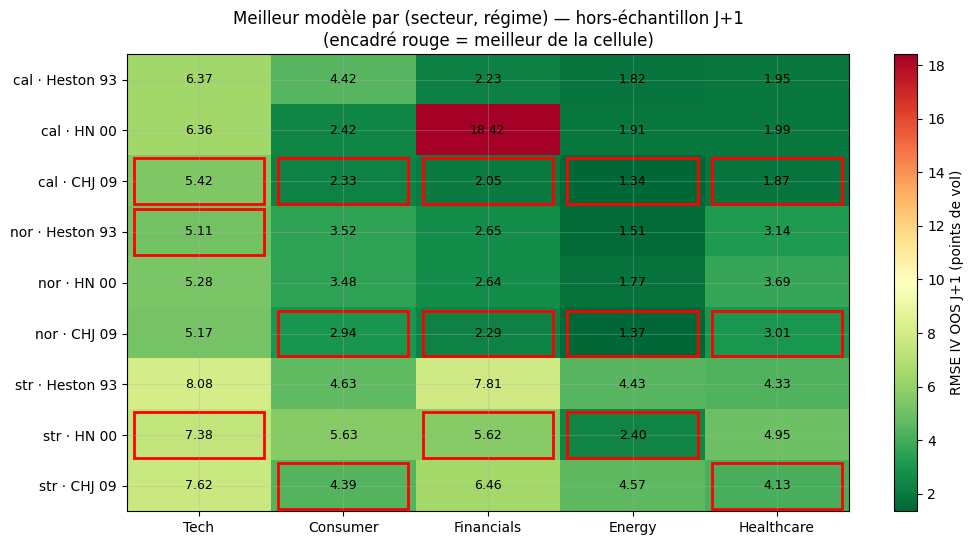

In [7]:
# Pivot : (régime × modèle) en lignes, secteurs en colonnes — OOS J+1, points de vol
sectors = sectors_present(metrics, SECTOR_MAP)
pivot = (
    metrics.groupby(['regime', 'model', 'sector'])['oos_rmse_iv_J1']
    .mean()
    .unstack('sector')
) * 100
ordered_idx = [(r, m) for r in REGIME_ORDER for m in MODELS]
pivot = pivot.reindex(ordered_idx)
pivot = pivot[sectors]  # colonnes dans l'ordre des secteurs déclarés

fig, ax = plt.subplots(figsize=(1.5 * len(sectors) + 3, 0.45 * len(pivot) + 1.5))
im = ax.imshow(pivot.values, cmap='RdYlGn_r', aspect='auto')

for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = pivot.values[i, j]
        if pd.notna(v):
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    fontsize=9, color='black')

# Encadrer le meilleur modèle par (secteur, régime)
from matplotlib.patches import Rectangle
for s_idx, sec in enumerate(sectors):
    for r in REGIME_ORDER:
        block = pivot.loc[r, sec]
        if block.isna().all(): continue
        best_model = block.idxmin()
        best_row = ordered_idx.index((r, best_model))
        ax.add_patch(Rectangle((s_idx - 0.45, best_row - 0.45), 0.9, 0.9,
                                fill=False, edgecolor='red', linewidth=2))

ax.set_xticks(range(len(sectors)))
ax.set_xticklabels(sectors)
ax.set_yticks(range(len(ordered_idx)))
ax.set_yticklabels([f'{r[:3]} · {MODEL_NAMES[m]}' for r, m in ordered_idx])
plt.colorbar(im, ax=ax, label='RMSE IV OOS J+1 (points de vol)')
ax.set_title('Meilleur modèle par (secteur, régime) — hors-échantillon J+1\n'
             '(encadré rouge = meilleur de la cellule)')
plt.tight_layout()
plt.savefig('../results/figures/05_heatmap_synthesis.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Ce que je retiens

**Ce qui marche.**
- CHJ fitte mieux la surface : ~2.9 points de vol de RMSE IV in-sample contre
  ~3.5 pour Heston et HN, et l'avantage tient encore à J+1 (meilleur modèle
  dans 11 cellules sur 15). Le second facteur de variance aide vraiment sur la
  term structure, comme annoncé dans le papier de 2009.
- Heston reste très compétitif rapporté à son coût : 5 paramètres, ~30 s par
  calibration (contre ~3 min pour HN et CHJ), et jamais très loin de CHJ.
- La mise à jour GARCH de HN paie sur les horizons longs : à J+15 c'est le
  modèle le plus stable (~5.4 points de vol contre ~5.9 pour les deux autres).
  C'est cohérent avec sa construction : le filtre réinjecte l'information des
  returns réalisés là où Heston et CHJ gardent un V₀ daté.

**Ce qui marche moins bien.**
- L'avantage in-sample de CHJ s'érode avec l'horizon et a disparu à J+15 :
  c'est la signature classique du sur-ajustement d'un modèle plus riche
  recalibré chaque jour.
- La calibration de CHJ est fragile : 63 % de convergence déclarée seulement,
  même avec 7 départs. Dans 13 cas sur 60, Heston fait mieux in-sample alors
  que c'est théoriquement impossible (modèles emboîtés) — ces cas mesurent
  l'échec de l'optimisation, pas la qualité du modèle.
- En régime stressé, aucun modèle ne survit à la semaine : le RMSE IV passe de
  ~3.5 points in-sample à 15-18 points à J+3/J+7 (avril 2025, la surface
  bouge trop vite pour des paramètres figés), avant de redescendre à J+15
  quand le marché se calme. HN limite un peu la casse grâce au filtre.
- Aucun des trois modèles ne capture l'aile gauche des smiles courts (puts OTM),
  visible sur les figures de la section 3 : il faudrait un terme de sauts
  (Bates 1996).

**Prudence.** 6 dates de calibration par ticker, c'est peu ; les écarts fins
entre modèles (surtout à J+15) sont dans le bruit. Les constats robustes sont
l'ordre in-sample, le coût de calcul, et l'effondrement commun en régime
stressé.